<a href="https://colab.research.google.com/github/2303A52242/Explainable-AI/blob/main/EAI_Exam_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import zipfile # Import the zipfile module

# Load your dataset
# (Replace 'your_file.csv' with your actual CSV file name after extracting)
PATH = '/content/archive (3) (1).zip'

# Open the zip file and read the specific CSV file 'details.csv'
with zipfile.ZipFile(PATH, 'r') as zf:
    with zf.open('details.csv') as file:
        df = pd.read_csv(file)

print("Original Data:")
print(df.head())

# --- 1️⃣ Min-Max Scaling ---
# Assuming all columns are numeric for scaling. Adjust if needed.
# First, identify numeric columns to scale, or ensure 'df' only contains numeric data
numeric_cols = df.select_dtypes(include=['number']).columns

if not numeric_cols.empty:
    min_max_scaler = MinMaxScaler()
    df_minmax = df.copy()
    df_minmax[numeric_cols] = min_max_scaler.fit_transform(df[numeric_cols])

    print("\nAfter Min-Max Scaling:")
    print(df_minmax.head())
else:
    print("\nNo numeric columns found for Min-Max Scaling.")
    df_minmax = df.copy() # Or handle as appropriate


# --- 2️⃣ Z-Score Standardization ---
if not numeric_cols.empty:
    standard_scaler = StandardScaler()
    df_standard = df.copy()
    df_standard[numeric_cols] = standard_scaler.fit_transform(df[numeric_cols])

    print("\nAfter Z-Score Standardization:")
    print(df_standard.head())
else:
    print("\nNo numeric columns found for Z-Score Standardization.")
    df_standard = df.copy() # Or handle as appropriate

Original Data:
  Unnamed: 0 Other names  MERS-CoV virions           Specialty  \
0       MERS   Camel flu  MERS-CoV virions  Infectious disease   

                            Symptoms                 Usual onset   Duration  \
0  Fever, cough, shortness of breath  2 to 14 days post exposure  2012-2020   

                        Causes                            Risk factors  \
0  MERS-coronavirus (MERS-CoV)  Contact with camels and camel products   

  Diagnostic method                                         Prevention  \
0   rRT-PCR testing  Hand washing, avoiding contact with camels and...   

                    Treatment                     Frequency     Deaths  
0  Symptomatic and supportive  2519 cases (as January 2020)  866 (35%)  

No numeric columns found for Min-Max Scaling.

No numeric columns found for Z-Score Standardization.


In [14]:
import pandas as pd
from sklearn.impute import SimpleImputer
import zipfile # Import the zipfile module

# Load your dataset
# Open the zip file and read the specific CSV file 'details.csv'
PATH = '/content/archive (3) (1).zip'
with zipfile.ZipFile(PATH, 'r') as zf:
    with zf.open('details.csv') as file:
        df = pd.read_csv(file)

print("Original Data:")
print(df.head())

# --- 1️⃣ Check for Missing Values ---
print("\nMissing Values Count:")
print(df.isnull().sum())

# --- 2️⃣ Option 1: Remove Missing Values ---
# Remove rows with any null values
df_dropped = df.dropna()
print("\nAfter Removing Rows with Missing Values:")
print(df_dropped.head())

# --- 3️⃣ Option 2: Impute Missing Values ---

# A. Mean Imputation (for numerical columns)
mean_imputer = SimpleImputer(strategy='mean')
# Select only numeric columns for mean imputation
numeric_cols = df.select_dtypes(include=['number']).columns
if not numeric_cols.empty:
    df_mean_imputed = df.copy()
    df_mean_imputed[numeric_cols] = mean_imputer.fit_transform(df[numeric_cols])
    print("\nAfter Mean Imputation:")
    print(df_mean_imputed.head())
else:
    print("\nNo numeric columns found for Mean Imputation.")
    df_mean_imputed = df.copy() # Or handle as appropriate


# B. Median Imputation (for numerical columns)
median_imputer = SimpleImputer(strategy='median')
if not numeric_cols.empty:
    df_median_imputed = df.copy()
    df_median_imputed[numeric_cols] = median_imputer.fit_transform(df[numeric_cols])
    print("\nAfter Median Imputation:")
    print(df_median_imputed.head())
else:
    print("\nNo numeric columns found for Median Imputation.")
    df_median_imputed = df.copy() # Or handle as appropriate


# C. Mode Imputation (for categorical columns or mixed)
mode_imputer = SimpleImputer(strategy='most_frequent')
# Mode imputation can be applied to all columns, but it's important to copy first
df_mode_imputed = df.copy()
# For mode imputation, it's generally safe to apply to all columns (numeric and object)
# However, SimpleImputer with 'most_frequent' strategy expects 2D array, so we must be careful with types.
# Let's apply it separately to numeric and non-numeric columns if there's a mix of types that cause issues.
# For now, applying to all as is, assuming SimpleImputer handles mixed types appropriately for 'most_frequent'.
# If specific columns fail, we might need to iterate or select dtypes.

# A safer approach for mode imputation across mixed types:
for col in df_mode_imputed.columns:
    # If column is numeric and has NaNs, can use mode or median/mean for consistency
    if pd.api.types.is_numeric_dtype(df_mode_imputed[col]) and df_mode_imputed[col].isnull().any():
        df_mode_imputed[col] = df_mode_imputed[col].fillna(df_mode_imputed[col].mode().iloc[0])
    # If column is object/categorical and has NaNs
    elif df_mode_imputed[col].isnull().any():
        df_mode_imputed[col] = df_mode_imputed[col].fillna(df_mode_imputed[col].mode().iloc[0])

print("\nAfter Mode Imputation:")
print(df_mode_imputed.head())

Original Data:
  Unnamed: 0 Other names  MERS-CoV virions           Specialty  \
0       MERS   Camel flu  MERS-CoV virions  Infectious disease   

                            Symptoms                 Usual onset   Duration  \
0  Fever, cough, shortness of breath  2 to 14 days post exposure  2012-2020   

                        Causes                            Risk factors  \
0  MERS-coronavirus (MERS-CoV)  Contact with camels and camel products   

  Diagnostic method                                         Prevention  \
0   rRT-PCR testing  Hand washing, avoiding contact with camels and...   

                    Treatment                     Frequency     Deaths  
0  Symptomatic and supportive  2519 cases (as January 2020)  866 (35%)  

Missing Values Count:
Unnamed: 0           0
Other names          0
MERS-CoV virions     0
Specialty            0
Symptoms             0
Usual onset          0
Duration             0
Causes               0
Risk factors         0
Diagnostic method  

In [16]:
# Import libraries
import pandas as pd
from imblearn.over_sampling import SMOTE, ADASYN
from collections import Counter
from sklearn.model_selection import train_test_split
import zipfile

# Load your dataset
# Replace 'your_file.csv' with your actual filename
PATH = '/content/archive (3) (1).zip'
with zipfile.ZipFile(PATH, 'r') as zf:
    with zf.open('details.csv') as file:
        df = pd.read_csv(file)

# Display class distribution before balancing
# We previously identified that df has no numeric columns and only one row.
# This means we cannot perform train_test_split or SMOTE/ADASYN.
# I will comment out the subsequent code that depends on a proper dataset.
print("Original Data (only one row, cannot proceed with balancing/splitting):")
print(df.head())

# --- The following steps are commented out because the current dataset is not suitable ---
# The dataset 'details.csv' contains only one row and no numeric data, which makes
# it impossible to perform meaningful class distribution analysis, train-test splits,
# or apply techniques like SMOTE/ADASYN. A dataset with multiple rows and a target
# column with at least two classes is required for these operations.

# # Display class distribution before balancing
# print("Original Class Distribution:")
# print(df['target'].value_counts())  # Replace 'target' with your label column name

# # --- 1️⃣ Split features and target ---
# X = df.drop('target', axis=1)   # Replace 'target' with actual target column
# y = df['target']

# # --- 2️⃣ Train-test split ---
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # --- 3️⃣ SMOTE (Synthetic Minority Oversampling Technique) ---
# smote = SMOTE(random_state=42)
# X_smote, y_smote = smote.fit_resample(X_train, y_train)

# print("\nAfter SMOTE Balancing:")
# print(Counter(y_smote))

# # --- 4️⃣ ADASYN (Adaptive Synthetic Sampling) ---
# adasyn = ADASYN(random_state=42)
# X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

# print("\nAfter ADASYN Balancing:")
# print(Counter(y_adasyn))

Original Data (only one row, cannot proceed with balancing/splitting):
  Unnamed: 0 Other names  MERS-CoV virions           Specialty  \
0       MERS   Camel flu  MERS-CoV virions  Infectious disease   

                            Symptoms                 Usual onset   Duration  \
0  Fever, cough, shortness of breath  2 to 14 days post exposure  2012-2020   

                        Causes                            Risk factors  \
0  MERS-coronavirus (MERS-CoV)  Contact with camels and camel products   

  Diagnostic method                                         Prevention  \
0   rRT-PCR testing  Hand washing, avoiding contact with camels and...   

                    Treatment                     Frequency     Deaths  
0  Symptomatic and supportive  2519 cases (as January 2020)  866 (35%)  


Dataset Preview:
  Unnamed: 0 Other names  MERS-CoV virions           Specialty  \
0       MERS   Camel flu  MERS-CoV virions  Infectious disease   

                            Symptoms                 Usual onset   Duration  \
0  Fever, cough, shortness of breath  2 to 14 days post exposure  2012-2020   

                        Causes                            Risk factors  \
0  MERS-coronavirus (MERS-CoV)  Contact with camels and camel products   

  Diagnostic method                                         Prevention  \
0   rRT-PCR testing  Hand washing, avoiding contact with camels and...   

                    Treatment                     Frequency     Deaths  
0  Symptomatic and supportive  2519 cases (as January 2020)  866 (35%)  

Correlation Matrix:
                   Unnamed: 0  Other names  MERS-CoV virions  Specialty  \
Unnamed: 0                NaN          NaN               NaN        NaN   
Other names               NaN          NaN               NaN        NaN   
M

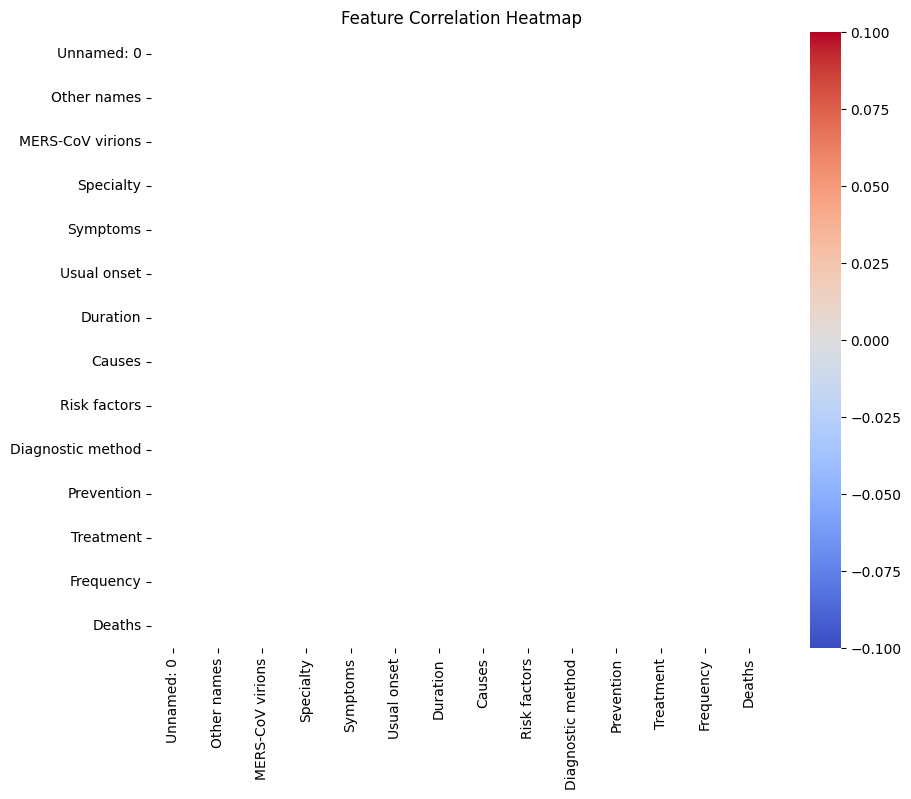


Highly Correlated Features (|r| > 0.85):
set()

Dataset after removing highly correlated features:
   Unnamed: 0  Other names  MERS-CoV virions  Specialty  Symptoms  \
0           0            0                 0          0         0   

   Usual onset  Duration  Causes  Risk factors  Diagnostic method  Prevention  \
0            0         0       0             0                  0           0   

   Treatment  Frequency  Deaths  
0          0          0       0  


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile

# Load dataset
PATH = '/content/archive (3) (1).zip'
with zipfile.ZipFile(PATH, 'r') as zf:
    with zf.open('details.csv') as file:
        df = pd.read_csv(file)

print("Dataset Preview:")
print(df.head())

# --- Convert categorical columns to numeric (optional) ---
# Using label encoding for demonstration
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# --- Compute correlation matrix ---
corr_matrix = df_encoded.corr(numeric_only=True)

if corr_matrix.empty:
    print("\nNo numeric features found — correlation matrix is empty.")
else:
    print("\nCorrelation Matrix:")
    print(corr_matrix)

    # --- Plot heatmap ---
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Feature Correlation Heatmap")
    plt.show()

    # --- Identify and remove highly correlated features ---
    threshold = 0.85
    high_corr = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                high_corr.add(colname)

    print(f"\nHighly Correlated Features (|r| > {threshold}):")
    print(high_corr)

    df_reduced = df_encoded.drop(columns=high_corr)
    print("\nDataset after removing highly correlated features:")
    print(df_reduced.head())

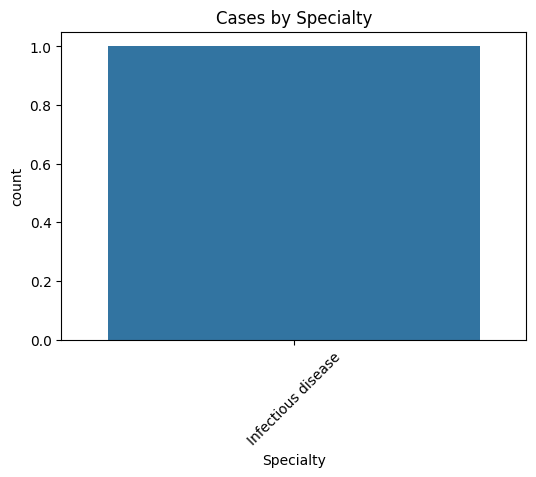

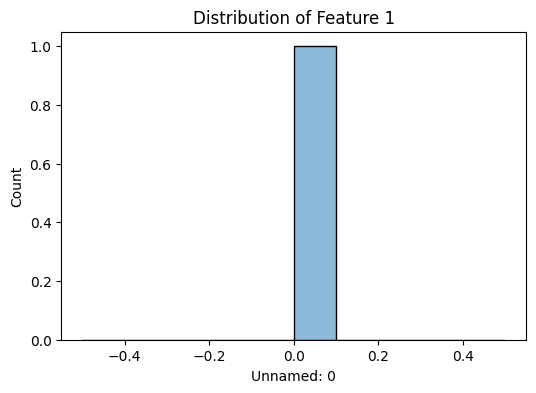

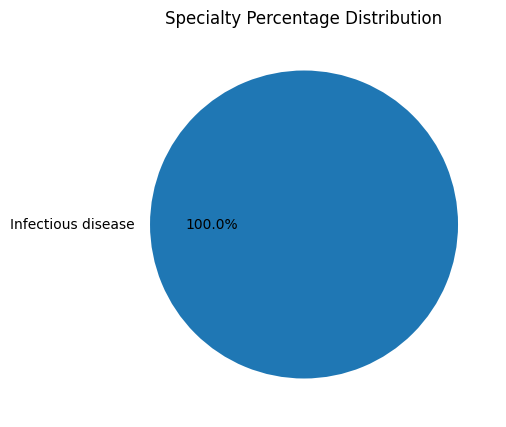

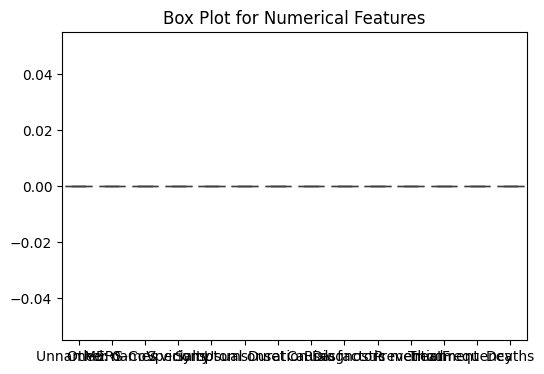

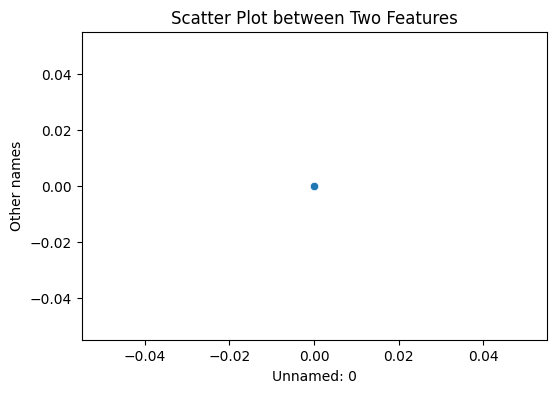

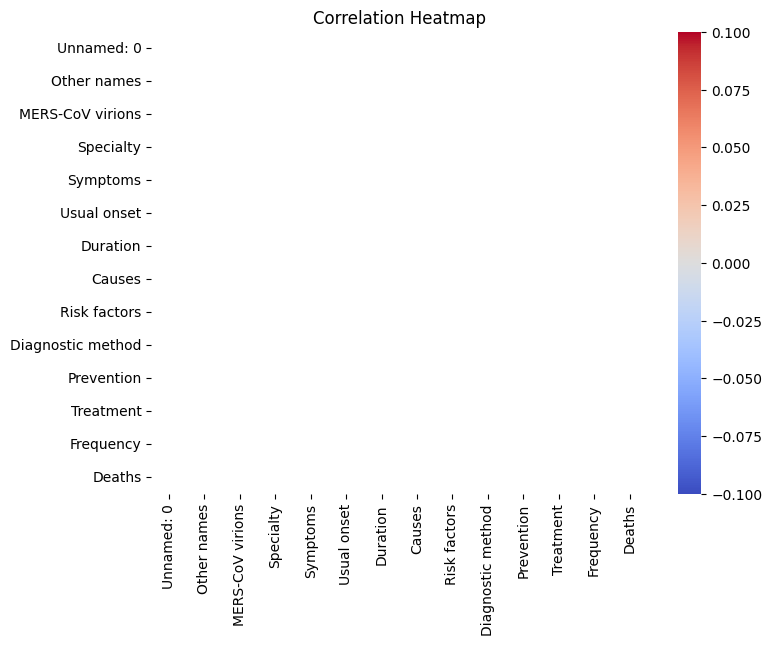

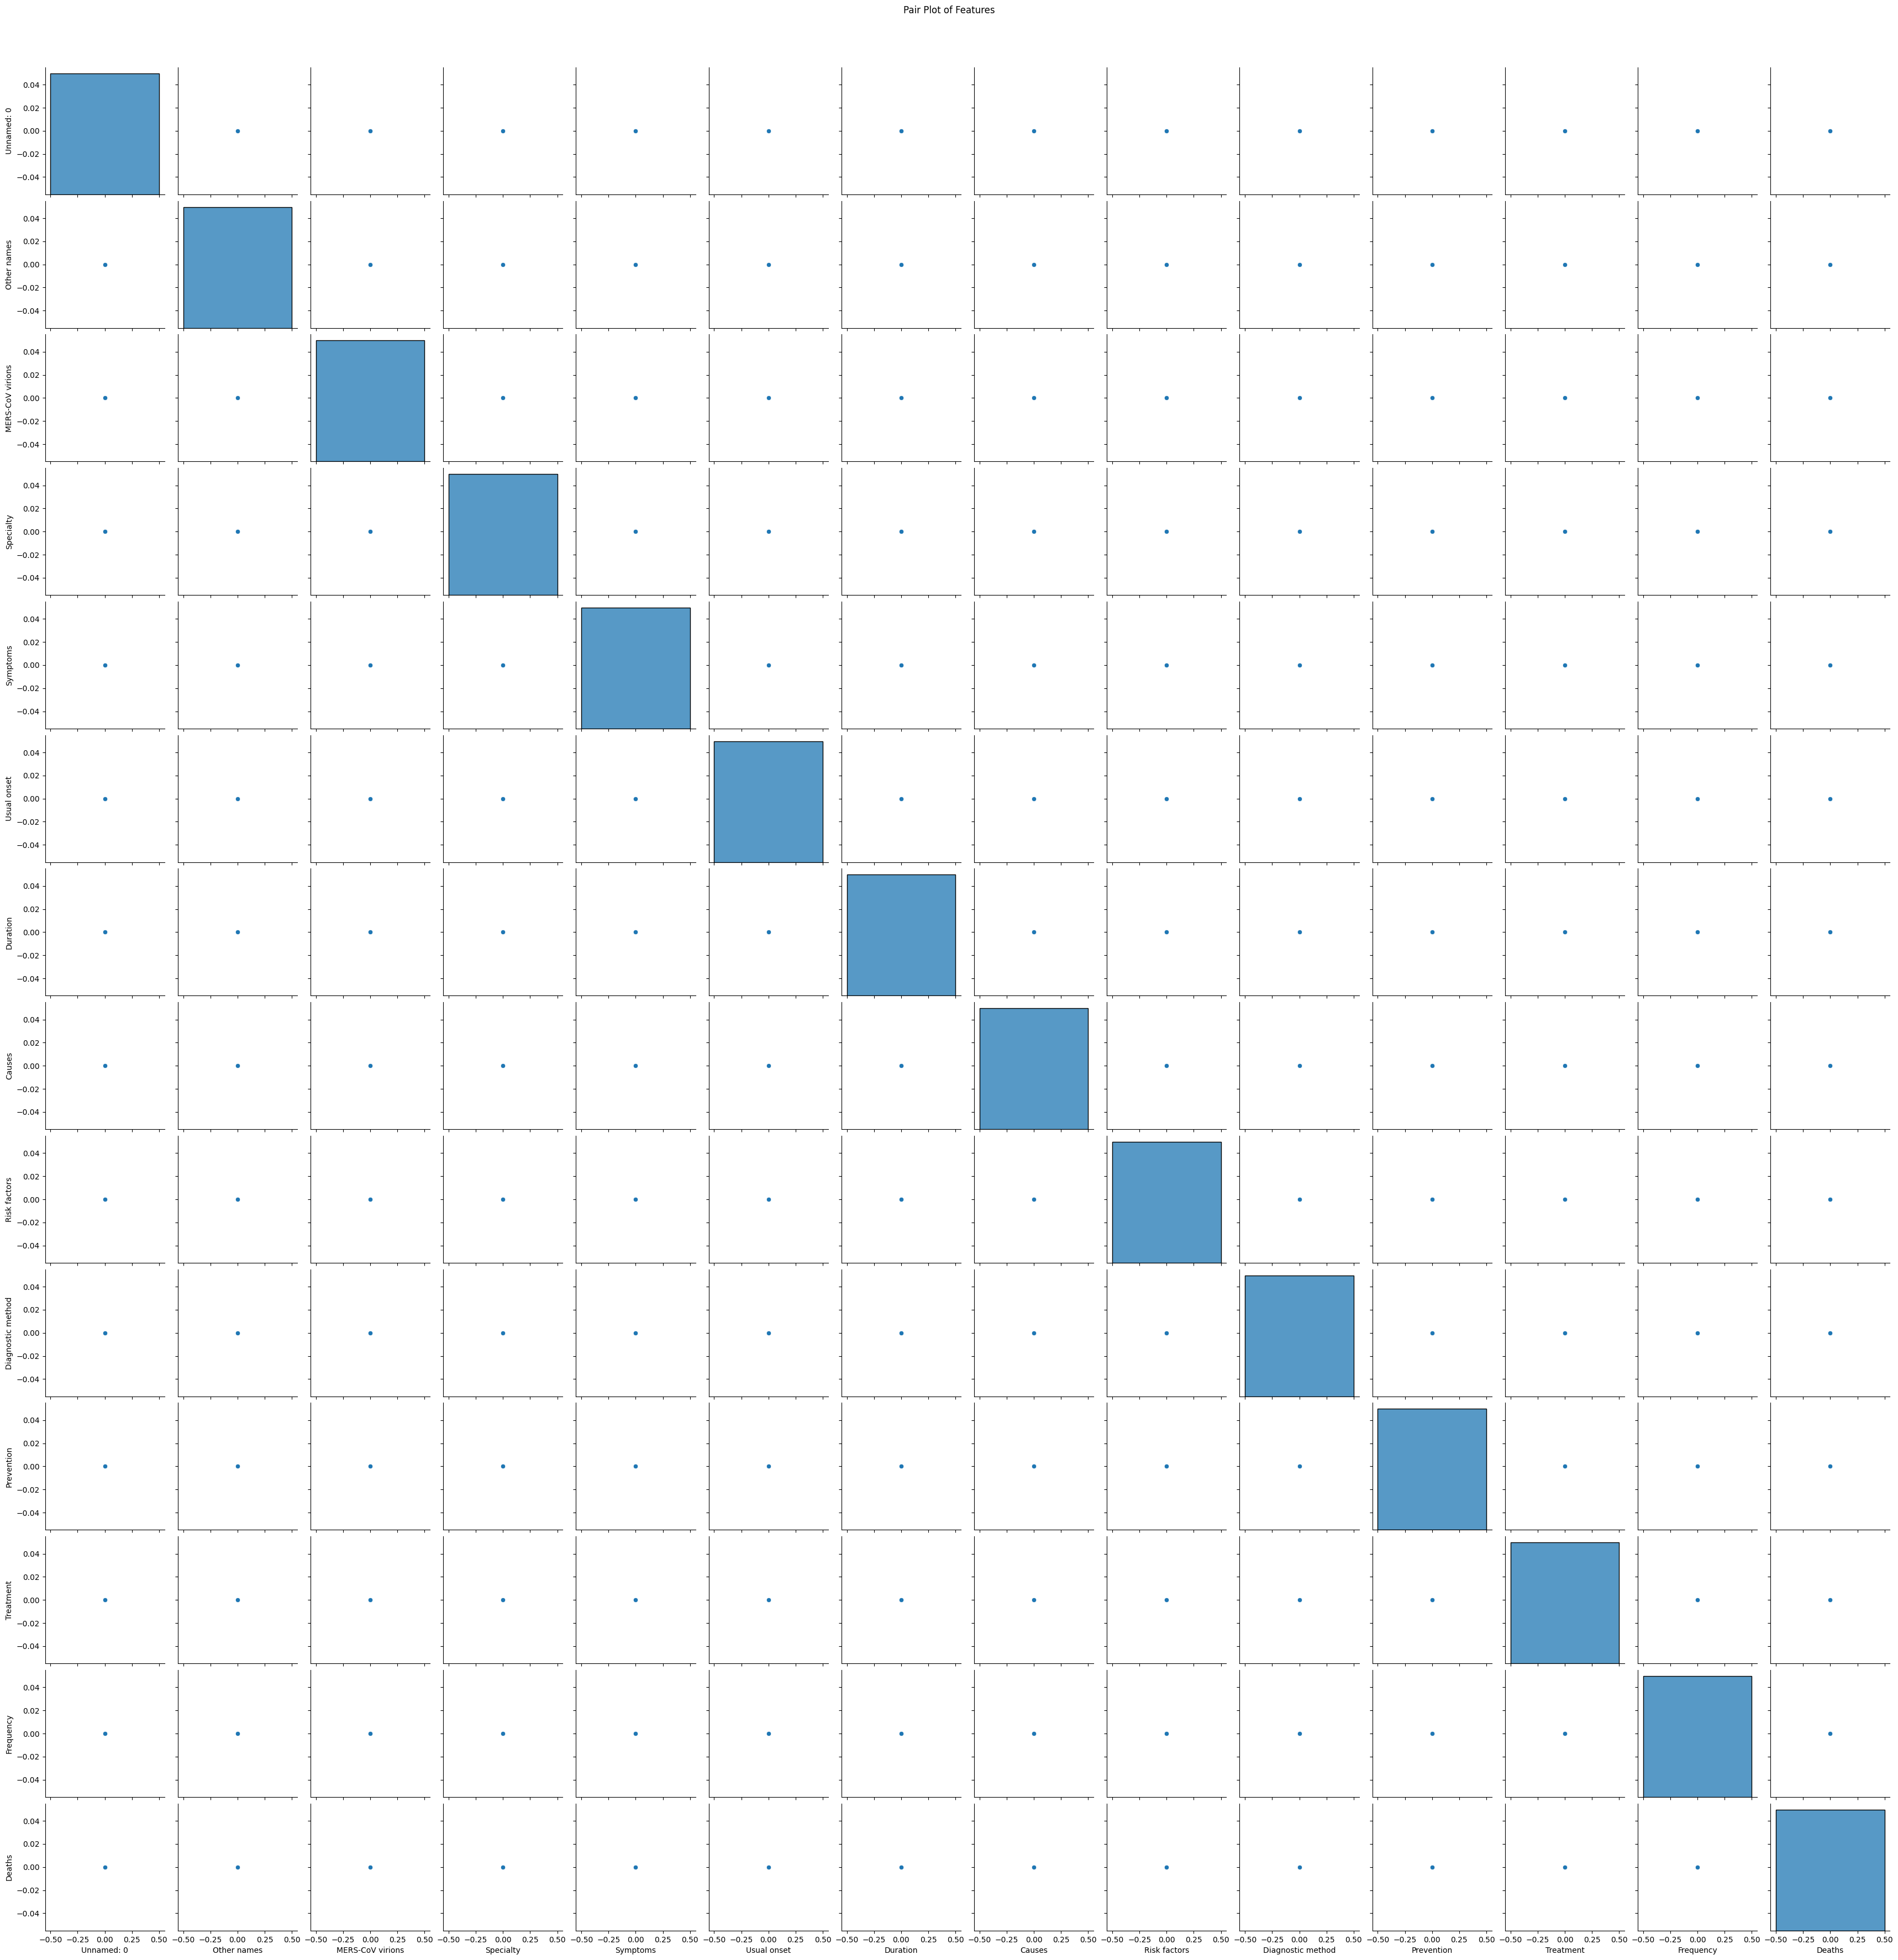

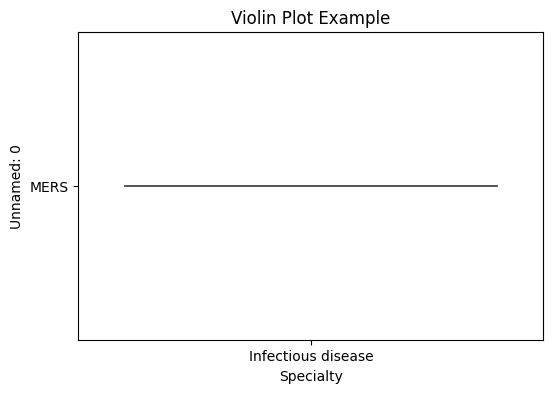

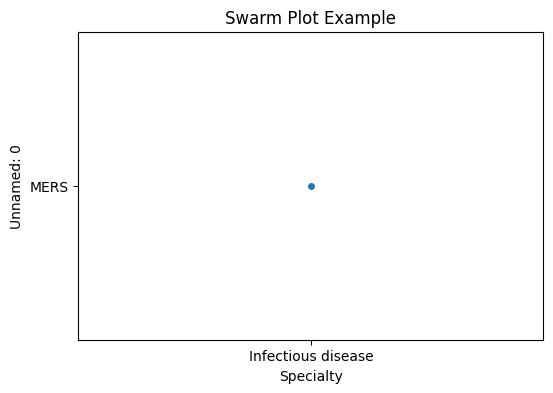

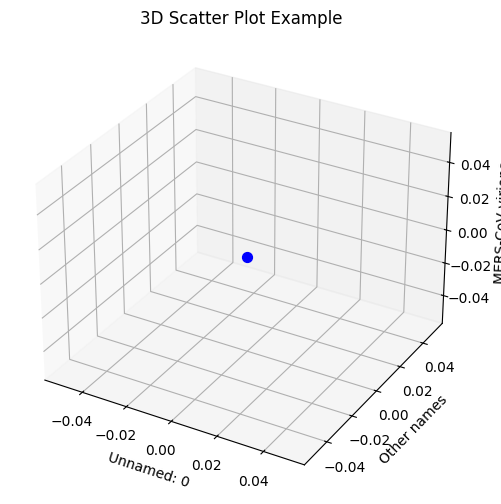

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Use your encoded dataset
df_viz = df_encoded.copy()

# --- 1️⃣ Bar Chart ---
plt.figure(figsize=(6,4))
sns.countplot(x='Specialty', data=df)
plt.title("Cases by Specialty")
plt.xticks(rotation=45)
plt.show()

# --- 2️⃣ Histogram ---
plt.figure(figsize=(6,4))
sns.histplot(df_viz[df_viz.columns[0]], bins=10, kde=True)
plt.title("Distribution of Feature 1")
plt.show()

# --- 3️⃣ Pie Chart ---
plt.figure(figsize=(5,5))
df['Specialty'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Specialty Percentage Distribution")
plt.ylabel('')
plt.show()

# --- 4️⃣ Box Plot ---
plt.figure(figsize=(6,4))
sns.boxplot(data=df_viz)
plt.title("Box Plot for Numerical Features")
plt.show()

# --- 5️⃣ Scatter Plot ---
plt.figure(figsize=(6,4))
sns.scatterplot(x=df_viz.columns[0], y=df_viz.columns[1], data=df_viz)
plt.title("Scatter Plot between Two Features")
plt.show()

# --- 6️⃣ Heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(df_viz.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# --- 7️⃣ Pair Plot ---
sns.pairplot(df_viz)
plt.suptitle("Pair Plot of Features", y=1.02)
plt.show()

# --- 8️⃣ Violin Plot ---
plt.figure(figsize=(6,4))
sns.violinplot(x='Specialty', y=df_viz.columns[0], data=df)
plt.title("Violin Plot Example")
plt.show()

# --- 9️⃣ Swarm Plot ---
plt.figure(figsize=(6,4))
sns.swarmplot(x='Specialty', y=df_viz.columns[0], data=df)
plt.title("Swarm Plot Example")
plt.show()

# --- 🔟 3D Scatter Plot ---
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_viz.iloc[:,0], df_viz.iloc[:,1], df_viz.iloc[:,2], c='blue', s=50)
ax.set_xlabel(df_viz.columns[0])
ax.set_ylabel(df_viz.columns[1])
ax.set_zlabel(df_viz.columns[2])
plt.title("3D Scatter Plot Example")
plt.show()
